# 13 · A real model's representations, region by region

Wrap a real pretrained ResNet-50 as a `BrainScoreModel`, record from the layers
mapped to V1, V2, V4, and IT, and look at what it represents. Category structure
sharpens along the hierarchy.

Laptop-safe: procedural stimuli, one cached model, CPU. ~30 s.

## Stimuli

24 images in four visually distinct groups (six each).

In [1]:
import os
os.environ['RESULTCACHING_DISABLE'] = '1'   # reproducible, no cache artifacts

import tempfile
import numpy as np
import pandas as pd
from PIL import Image
from brainscore_core.supported_data_standards.brainio.stimuli import StimulusSet

CATS = ['warm-stripes', 'cool-stripes', 'green-blobs', 'gray-noise']

def make_image(cat, k):
    r = np.random.RandomState(hash((cat, k)) % 2**31)
    x = np.zeros((224, 224, 3), np.float32)
    yy, xx = np.mgrid[0:224, 0:224]
    if cat == 'warm-stripes':
        s = (np.sin(xx / (6 + r.rand() * 4)) + 1) / 2
        x[..., 0] = 200 * s + 40; x[..., 1] = 90 * s + 20
    elif cat == 'cool-stripes':
        s = (np.sin(yy / (6 + r.rand() * 4)) + 1) / 2
        x[..., 2] = 200 * s + 40; x[..., 1] = 80 * s + 20
    elif cat == 'green-blobs':
        for _ in range(25):
            cy, cx = r.randint(20, 204, 2); rad = r.randint(8, 20)
            m = ((yy - cy) ** 2 + (xx - cx) ** 2) < rad ** 2
            x[m, 1] += 150; x[m, 0] += 40
    else:  # gray-noise
        n = np.kron(r.rand(56, 56, 1), np.ones((4, 4, 1)))
        x[:] = 80 + 120 * n
    x += r.randn(224, 224, 3) * 6
    return np.clip(x, 0, 255).astype(np.uint8)

d = tempfile.mkdtemp()
rows, labels = [], []
for ci, cat in enumerate(CATS):
    for k in range(6):
        p = os.path.join(d, f'{cat}_{k}.png')
        Image.fromarray(make_image(cat, k)).save(p)
        rows.append({'stimulus_id': f'{cat}_{k}', 'image_file_name': p})
        labels.append(ci)
labels = np.array(labels)

stimuli = StimulusSet(pd.DataFrame(rows))
stimuli.identifier = 'showcase-stimuli'
stimuli.stimulus_paths = {r['stimulus_id']: r['image_file_name'] for r in rows}
print(f'{len(stimuli)} stimuli across {len(CATS)} categories')

24 stimuli across 4 categories


## See the stimuli

What the four groups actually look like (first four of six each).

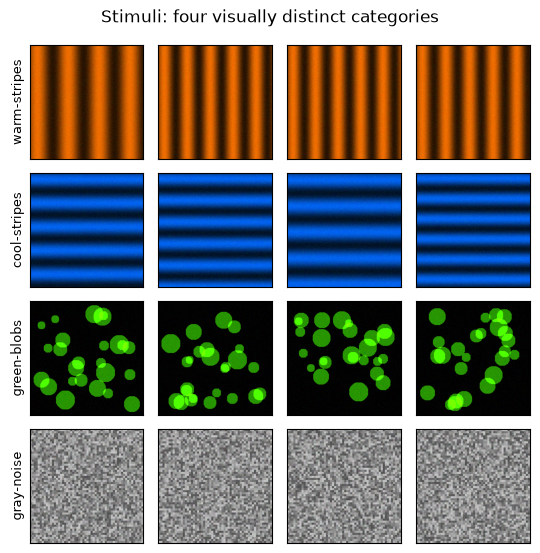

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(CATS), 4, figsize=(5.5, 5.6))
for ci, cat in enumerate(CATS):
    for k in range(4):
        ax = axes[ci, k]
        ax.imshow(make_image(cat, k)); ax.set_xticks([]); ax.set_yticks([])
        if k == 0: ax.set_ylabel(cat, fontsize=9)
fig.suptitle('Stimuli: four visually distinct categories')
fig.tight_layout(); plt.show()

## Wrap a real pretrained model

A pretrained ResNet-50 (ImageNet weights) wrapped as a `BrainScoreModel`. The
`region_layer_map` ties each brain region to a network layer.

In [3]:
import torchvision.models as tvm
from brainscore_core.model_interface import BrainScoreModel
from brainscore_vision.model_helpers.activations.pytorch import (
    PytorchWrapper, load_preprocess_images)

resnet = tvm.resnet50(weights=tvm.ResNet50_Weights.IMAGENET1K_V2).eval()
activations = PytorchWrapper(
    identifier='resnet50-pretrained', model=resnet,
    preprocessing=lambda x: load_preprocess_images(x, image_size=224))

model = BrainScoreModel(
    identifier='resnet50-pretrained',
    model=resnet,
    region_layer_map={'V1': 'layer1', 'V2': 'layer2', 'V4': 'layer3', 'IT': 'layer4'},
    preprocessors={'vision': lambda x: x},
    activations_model=activations)
print('regions:', list(model.region_layer_map))

regions: ['V1', 'V2', 'V4', 'IT']


## Record each region

`start_recording(region)` then `process(stimuli)`, one region at a time.

In [4]:
REGIONS = ['V1', 'V2', 'V4', 'IT']
features = {}
for region in REGIONS:
    model.start_recording(region)
    assembly = model.process(stimuli)
    features[region] = np.asarray(assembly.values)
    print(f'{region}: {features[region].shape}')

V1: (24, 802816)


V2: (24, 401408)


V4: (24, 200704)


IT: (24, 100352)


## What IT represents

A representational dissimilarity matrix: `1 - correlation` between every pair of
stimulus feature vectors at IT, ordered by category. Read it like a map:

- **Dark 6x6 blocks on the diagonal** = pairs within one category -> similar
  representations (low dissimilarity).
- **Bright off-diagonal** = pairs across categories -> dissimilar.

Crisp diagonal blocks mean IT cleanly separates the categories.

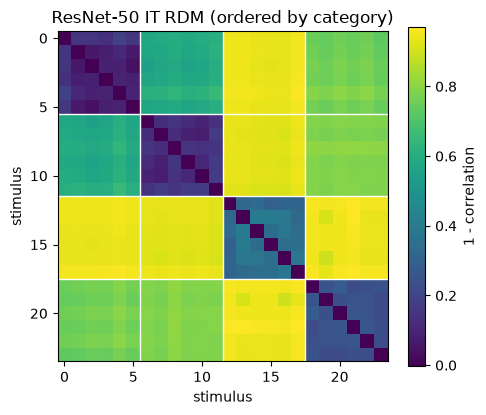

In [5]:
import matplotlib.pyplot as plt

def rdm(F):
    F = F - F.mean(1, keepdims=True)
    F = F / (np.linalg.norm(F, axis=1, keepdims=True) + 1e-8)
    return 1 - (F @ F.T)

order = np.argsort(labels, kind='stable')
D_it = rdm(features['IT'])[np.ix_(order, order)]

fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(D_it, cmap='viridis')
for b in np.cumsum([6, 6, 6]):
    ax.axhline(b - 0.5, c='w', lw=1); ax.axvline(b - 0.5, c='w', lw=1)
ax.set_title('ResNet-50 IT RDM (ordered by category)')
ax.set_xlabel('stimulus'); ax.set_ylabel('stimulus')
fig.colorbar(im, label='1 - correlation'); fig.tight_layout(); plt.show()

## The same representation as clusters

MDS embeds the IT dissimilarities into 2D.

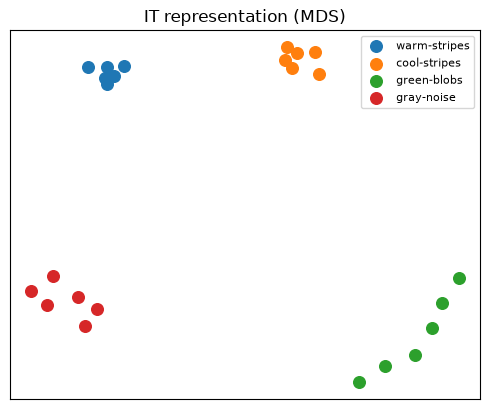

In [6]:
from sklearn.manifold import MDS

emb = MDS(n_components=2, dissimilarity='precomputed', random_state=0,
          normalized_stress='auto').fit_transform(rdm(features['IT']))
fig, ax = plt.subplots(figsize=(5, 4.2))
for ci, cat in enumerate(CATS):
    m = labels == ci
    ax.scatter(emb[m, 0], emb[m, 1], label=cat, s=70)
ax.set_title('IT representation (MDS)'); ax.legend(fontsize=8)
ax.set_xticks([]); ax.set_yticks([]); fig.tight_layout(); plt.show()

## Structure sharpens along the hierarchy

Separability = mean between-category distance / mean within-category distance.
1.0 means no separation.

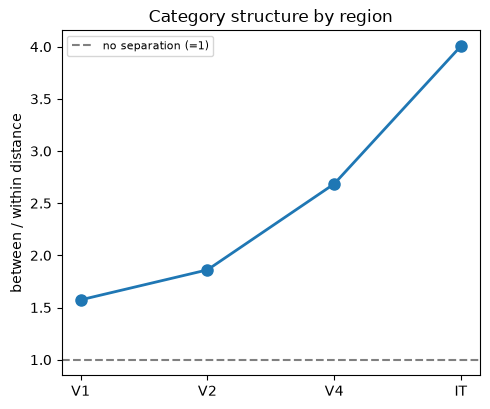

{'V1': 1.57, 'V2': 1.86, 'V4': 2.69, 'IT': 4.01}


In [7]:
def separability(F, lab):
    D = rdm(F); within, between = [], []
    for i in range(len(lab)):
        for j in range(i + 1, len(lab)):
            (within if lab[i] == lab[j] else between).append(D[i, j])
    return np.mean(between) / np.mean(within)

sep = [separability(features[r], labels) for r in REGIONS]
fig, ax = plt.subplots(figsize=(5, 4.2))
ax.plot(range(len(REGIONS)), sep, 'o-', lw=2, ms=8)
ax.axhline(1, ls='--', c='gray', label='no separation (=1)')
ax.set_xticks(range(len(REGIONS))); ax.set_xticklabels(REGIONS)
ax.set_ylabel('between / within distance')
ax.set_title('Category structure by region'); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()
print({r: round(s, 2) for r, s in zip(REGIONS, sep)})

This is representation structure, not brain alignment. To score a real model
against neural data, use the benchmark path:
`brainscore.score('resnet50-pretrained', '<benchmark>')` — heavier, and covered
in the getting-started guide.